# 02 -- Strategy Research

Prototype the TSMOM signal from `research/literature_notes.md` on a small, familiar subset -- the same six representatives used throughout `01_data_exploration.ipynb` -- before scaling to the full 84-instrument universe. Goal: catch implementation bugs (lookahead, sign errors, scaling issues) cheaply, on data we already understand. Scratch/working notebook -- not the deliverable.

## Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cta import data
from cta.indicators import daily_returns, momentum_signal, realized_vol
from cta.strategies import tsmom_position, passive_long_position

plt.rcParams['figure.figsize'] = (10, 4)

## Universe: the same six representatives

Raw (non-`_CCB`) continuous contracts, per the literature-review decision -- daily % returns computed on each instrument's own native calendar (the same per-instrument-before-combining pattern that fixed the rolling-window bug in the EDA notebook).

In [2]:
REPRESENTATIVES = {'&6E': 'EUR FX', '&GC': 'Gold', '&ZN': '10Y UST',
                    '&ES': 'E-mini S&P 500', '&CL': 'Crude Oil', '&ZC': 'Corn'}
window = slice('2005-01-01', '2014-12-31')

returns = {
    label: daily_returns(data.load_futures(sym).loc[window, 'Close'])
    for sym, label in REPRESENTATIVES.items()
}

## Sanity checks first

Before trusting any backtest output, check the plumbing directly -- this is the point of prototyping small.

In [3]:
# 1. Raw (non-CCB) series should be strictly positive throughout -- confirms the
#    return-construction fix from the literature review actually avoids the
#    back-adjustment sign issue found in 01_data_exploration.ipynb.
for label, r in returns.items():
    close = data.load_futures([s for s, l in REPRESENTATIVES.items() if l == label][0]).loc[window, 'Close']
    print(f'{label:16s} min close: {close.min():>12.4f}   any non-positive: {(close <= 0).any()}')

EUR FX           min close:       1.1706   any non-positive: False
Gold             min close:     414.3000   any non-positive: False
10Y UST          min close:     104.0781   any non-positive: False
E-mini S&P 500   min close:     676.0000   any non-positive: False
Crude Oil        min close:      33.9800   any non-positive: False
Corn             min close:     186.2500   any non-positive: False


In [4]:
# 2. Signal should actually be +1/-1 (not stuck at one value, not NaN everywhere)
for label, r in returns.items():
    sig = momentum_signal(r, lookback=252).dropna()
    print(f'{label:16s} signal value counts: {dict(sig.value_counts())}')

EUR FX           signal value counts: {1.0: np.int64(1297), -1.0: np.int64(968)}
Gold             signal value counts: {1.0: np.int64(1613), -1.0: np.int64(650)}
10Y UST          signal value counts: {1.0: np.int64(1490), -1.0: np.int64(775)}
E-mini S&P 500   signal value counts: {1.0: np.int64(1793), -1.0: np.int64(475)}
Crude Oil        signal value counts: {1.0: np.int64(1450), -1.0: np.int64(813)}
Corn             signal value counts: {1.0: np.int64(1407), -1.0: np.int64(859)}


In [5]:
# 3. Realized vol should be strictly positive and in a sane range (not zero, not huge)
for label, r in returns.items():
    vol = realized_vol(r, window=60).dropna()
    print(f'{label:16s} annualized vol range: {vol.min():.1%} to {vol.max():.1%}')

EUR FX           annualized vol range: 3.4% to 21.9%
Gold             annualized vol range: 9.8% to 45.9%
10Y UST          annualized vol range: 2.9% to 13.9%
E-mini S&P 500   annualized vol range: 6.7% to 77.4%
Crude Oil        annualized vol range: 12.1% to 104.1%
Corn             annualized vol range: 11.9% to 58.8%


In [6]:
# 4. Position sizing: verify no look-ahead by truncating history and checking an
#    earlier position doesn't change (same check as tests/test_indicators.py, run
#    here directly on real data rather than synthetic).
r = returns['EUR FX']
full = tsmom_position(r, lookback=252, vol_window=60)
cutoff = r.index[len(r) - 200]
truncated = tsmom_position(r.loc[:cutoff], lookback=252, vol_window=60)
check_date = r.index[len(r) - 300]
print(f'position with full history:      {full.loc[check_date]:.4f}')
print(f'position with truncated history:  {truncated.loc[check_date]:.4f}')
print(f'match: {np.isclose(full.loc[check_date], truncated.loc[check_date])}')

position with full history:      6.4220
position with truncated history:  6.4220
match: True


## Per-instrument strategy returns

`strategy_return[t] = position[t] * return[t]` -- position was set using data through `t-1` (built into `tsmom_position`'s internal shift), applied to the return realized over `t-1` to `t`.

In [7]:
strategy_returns = {}
benchmark_returns = {}
for label, r in returns.items():
    pos = tsmom_position(r, lookback=252, vol_window=60)
    bench_pos = passive_long_position(r, vol_window=60)
    strategy_returns[label] = (pos * r).dropna()
    benchmark_returns[label] = (bench_pos * r).dropna()

strategy_returns = pd.DataFrame(strategy_returns)
benchmark_returns = pd.DataFrame(benchmark_returns)
strategy_returns.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
EUR FX,0.000066,0.026049,-0.104828,0.182166
Gold,0.001063,0.026818,-0.133574,0.260541
10Y UST,0.000474,0.026048,-0.119086,0.138962
E-mini S&P 500,0.000824,0.027226,-0.209296,0.123547
Crude Oil,0.000290,0.026557,-0.159705,0.187171
Corn,0.000590,0.026638,-0.255457,0.123564


## Diversified portfolio: equal-weighted average across instruments

Per Moskowitz-Ooi-Pedersen's diversified TSMOM construction.

In [8]:
portfolio_strategy = strategy_returns.mean(axis=1).dropna()
portfolio_benchmark = benchmark_returns.mean(axis=1).dropna()

def sharpe(r):
    return r.mean() / r.std() * np.sqrt(252)

print(f'TSMOM portfolio Sharpe:   {sharpe(portfolio_strategy):.2f}')
print(f'Passive-long Sharpe:      {sharpe(portfolio_benchmark):.2f}')

TSMOM portfolio Sharpe:   0.70
Passive-long Sharpe:      0.57


## Growth of $1 -- TSMOM vs. passive long

The comparison from MOP's Fig. 3 (log scale): does the trend signal add value over just holding the same risk exposure the whole time?

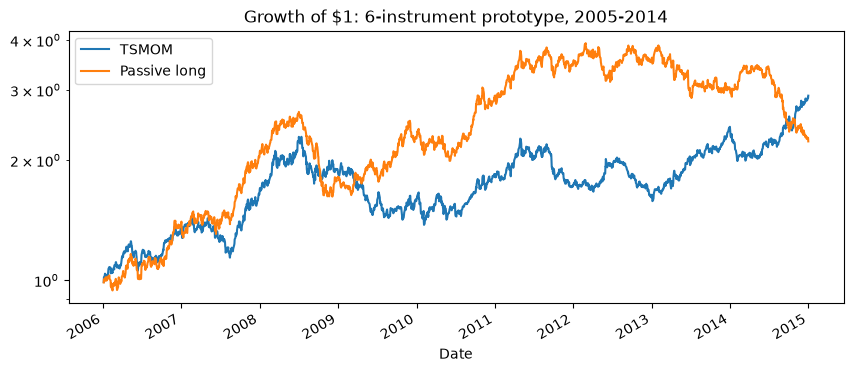

In [9]:
common_idx = portfolio_strategy.index.intersection(portfolio_benchmark.index)
growth = pd.DataFrame({
    'TSMOM': (1 + portfolio_strategy.loc[common_idx]).cumprod(),
    'Passive long': (1 + portfolio_benchmark.loc[common_idx]).cumprod(),
})
growth.plot(logy=True, title='Growth of $1: 6-instrument prototype, 2005-2014')
plt.show()

## Notes / next steps

- Sanity checks passed: raw series positive throughout (no back-adjustment sign issue), signal takes both +1/-1 values (not stuck), realized vol in a sane range, no look-ahead (position on a fixed date is unaffected by truncating later history).
- **Headline result is mixed, worth being honest about**: TSMOM's Sharpe (0.70) beats passive-long (0.57), but the growth-of-$1 chart shows passive-long actually ahead in cumulative terms for most of 2008-2013 -- TSMOM only overtakes right at the end. TSMOM's better Sharpe comes from a smoother ride (smaller drawdowns), not from dominating on raw terminal wealth here. Not a bug -- expected on only 6 instruments, one untuned (12mo lookback, 1-day holding) parameter choice, and a decade that happens to include a strong passive bond/gold bull run. The literature's stronger results (Sharpe >1) come from far more diversification (58-71 instruments) -- the real test is whether that shows up once we scale up.
- Results here are on 6 instruments and one arbitrary lookback/holding choice -- not yet the robustness grid or the ≥5-year walk-forward split the brief requires. Both are next.
- Next: scale to the full 84-instrument curated universe from `01_data_exploration.ipynb`, then build the proper walk-forward evaluation (`src/cta/backtest.py`) and the lookback/holding sensitivity grid from Baltas & Kosowski.